In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [282]:
df_avg = pd.read_csv("../../../data/processed/3_year/Goalkeeper/Avg_Top5_Goalkeepers.csv")
df_ewma = pd.read_csv("../../../data/processed/3_year/Goalkeeper/EWMA_Top5_Goalkeepers.csv")

In [283]:
outliers_to_drop = ['Sam Johnstone', 'Răzvan Sava']
df_avg = df_avg[~df_avg['player'].isin(outliers_to_drop)].reset_index(drop=True)
df_ewma = df_ewma[~df_ewma['player'].isin(outliers_to_drop)].reset_index(drop=True)


In [284]:
df_avg.head()

,player id,player,team,team id,league,position,number_of_seasons,goalsprevented,minutesplayed,rating,...,savescaught_per90,savesparried_per90,savedshotsfromoutsidethebox_per90,goalsprevented_per90,successfulrunsout_per90,goalkicks_per90,punches_per90,highclaims_per90,crossesnotclaimed_per90,owngoals_per90
0,8959,Manuel Neuer,FC Bayern München,2672,Germany Bundesliga,Goalkeepers,3,-1.026667,1964.666667,6.933433,...,0.045809,0.305395,0.580251,-0.047031,0.626060,3.573125,0.244316,0.290126,0.030540,0.0
1,15219,Lukáš Hrádecký,AS Monaco,1653,France Ligue 1,Goalkeepers,3,-0.823333,2340.333333,6.942152,...,0.025637,0.269192,0.935764,-0.031662,0.384561,4.909557,0.192280,0.551204,0.000000,0.0
2,16206,Yann Sommer,Inter,2697,Italy Serie A,Goalkeepers,3,1.526667,2997.000000,7.054300,...,0.000000,0.440440,0.900901,0.045846,0.180180,4.644645,0.250250,0.410410,0.010010,0.0
3,22209,Ørjan Nyland,Sevilla,2833,Spain La Liga,Goalkeepers,3,0.166667,1761.333333,6.887458,...,0.034065,0.476911,1.038986,0.008516,0.357684,6.659727,0.323618,0.545042,0.000000,0.0
4,37096,Péter Gulácsi,RB Leipzig,36360,Germany Bundesliga,Goalkeepers,3,1.070000,1937.000000,7.090152,...,0.030976,0.696954,0.696954,0.049716,0.464636,6.055756,0.480124,0.665978,0.015488,0.0


In [285]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['minutesplayed','rating','number_of_seasons'])
X_ewma=df_ewma.drop(columns=fl.metadata_features + ['minutesplayed','rating','number_of_seasons'])

In [286]:
X_avg.head()

,goalsprevented,accuratelongballspercentage,accuratepassespercentage,tackleswonpercentage,aerialduelswonpercentage,accuratelongballs_per90,errorleadtoshot_per90,errorleadtogoal_per90,aerialduelswon_per90,saves_per90,savescaught_per90,savesparried_per90,savedshotsfromoutsidethebox_per90,goalsprevented_per90,successfulrunsout_per90,goalkicks_per90,punches_per90,highclaims_per90,crossesnotclaimed_per90,owngoals_per90
0,-1.026667,52.902375,83.607266,50.000000,76.470588,6.123176,0.076349,0.091619,0.198507,1.878181,0.045809,0.305395,0.580251,-0.047031,0.626060,3.573125,0.244316,0.290126,0.030540,0.0
1,-0.823333,39.372822,72.459350,100.000000,88.235294,4.345535,0.025637,0.038456,0.192280,2.666287,0.025637,0.269192,0.935764,-0.031662,0.384561,4.909557,0.192280,0.551204,0.000000,0.0
2,1.526667,50.259605,85.049239,50.000000,72.727273,4.844845,0.020020,0.020020,0.080080,2.302302,0.000000,0.440440,0.900901,0.045846,0.180180,4.644645,0.250250,0.410410,0.010010,0.0
3,0.166667,32.846004,59.048179,66.666667,100.000000,5.739970,0.051098,0.051098,0.357684,2.776306,0.034065,0.476911,1.038986,0.008516,0.357684,6.659727,0.323618,0.545042,0.000000,0.0
4,1.070000,41.811847,81.789474,100.000000,90.476190,3.717088,0.030976,0.046464,0.294269,2.880743,0.030976,0.696954,0.696954,0.049716,0.464636,6.055756,0.480124,0.665978,0.015488,0.0


In [287]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)
X_ewma_scaled = scaler.fit_transform(X_ewma)

In [288]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

In [289]:
inertia_ewma = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_ewma_scaled)
    inertia_ewma.append(km.inertia_)

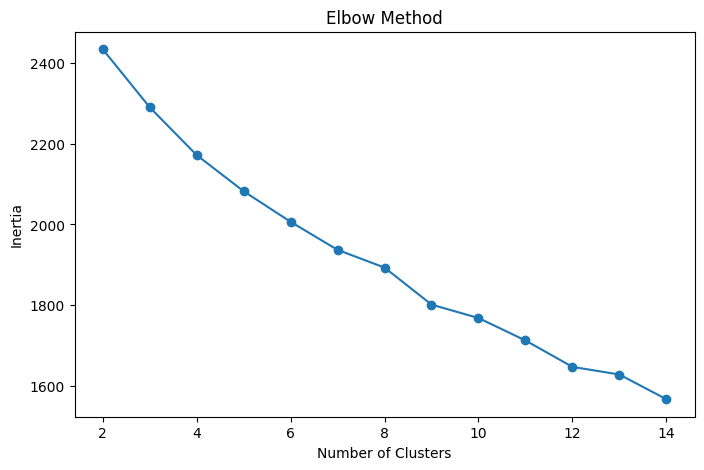

In [290]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

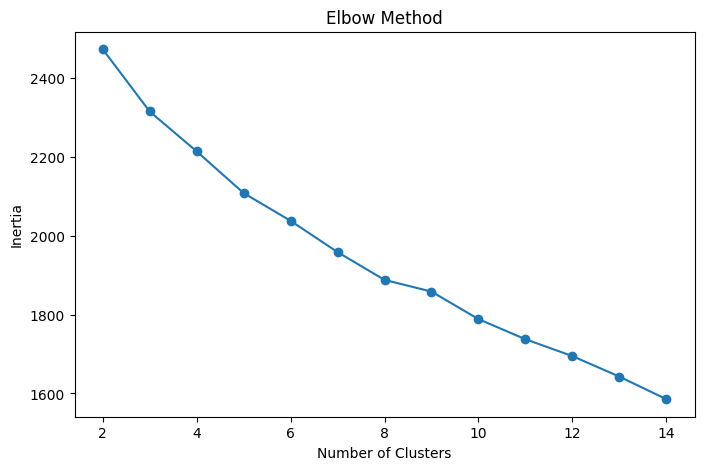

In [291]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_ewma,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [292]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

In [293]:
scores_ewma = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_ewma_scaled)
    
    score = silhouette_score(X_ewma_scaled, labels)
    scores_ewma.append(score)

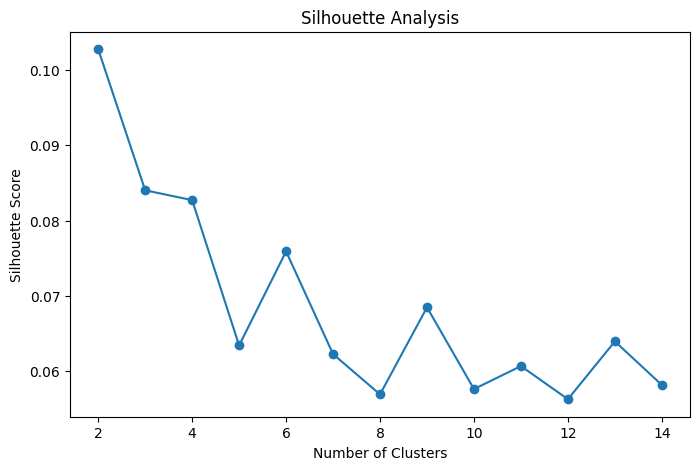

In [294]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

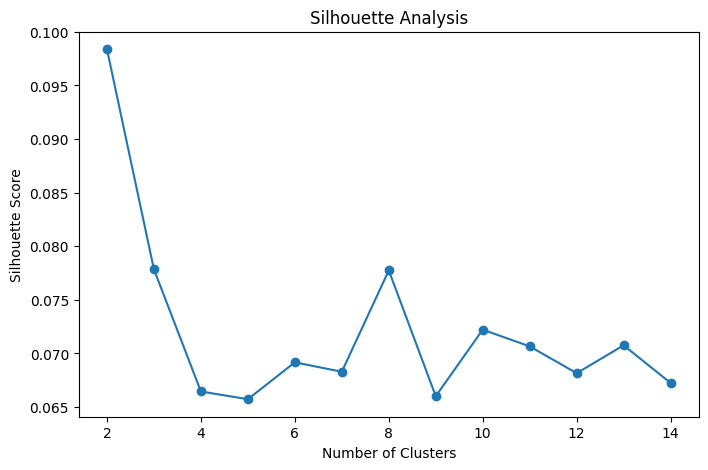

In [295]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_ewma,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [296]:
x=4
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [297]:
x=5
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_ewma_scaled)

df_ewma[f"cluster_{x}"] = labels

In [298]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby("cluster_4").mean())

display(cluster_avg_summary.transpose())

cluster_4,0,1,2,3
number_of_seasons,2.577778,2.400000,2.450000,2.545455
goalsprevented,1.463111,-1.294458,-0.511167,1.304798
minutesplayed,2173.970370,2165.966667,2121.258333,2226.303030
rating,7.042118,6.961838,7.015160,7.109417
accuratelongballspercentage,42.238465,38.908924,33.397200,38.530347
accuratepassespercentage,77.531998,67.861744,64.709482,66.002240
tackleswonpercentage,51.703704,19.708333,50.250000,49.819625
aerialduelswonpercentage,92.862031,89.474511,94.775800,91.362473
accuratelongballs_per90,4.951837,6.581533,5.423269,6.518137
errorleadtoshot_per90,0.040357,0.047192,0.062209,0.039058


In [299]:
cluster_ewma_summary = (df_ewma.drop(columns=fl.metadata_features).groupby("cluster_5").mean())

display(cluster_ewma_summary.transpose())

cluster_5,0,1,2,3,4
number_of_seasons,2.444444,2.406250,2.500000,2.555556,2.600000
goalsprevented,4.018683,-1.258702,-0.777780,-0.387619,1.079642
minutesplayed,2767.731217,2068.375000,1991.502381,2883.322751,1966.265608
rating,7.147811,7.006019,6.929881,6.994375,7.029648
accuratelongballspercentage,39.346455,36.878464,35.373875,37.480313,43.303481
accuratepassespercentage,66.020364,63.584371,67.286623,70.857281,77.763939
tackleswonpercentage,45.168350,35.376984,52.175926,61.851852,32.573124
aerialduelswonpercentage,85.334798,92.351098,94.632813,95.384645,91.542899
accuratelongballs_per90,7.194101,6.918150,5.345282,5.715530,5.057458
errorleadtoshot_per90,0.048372,0.048535,0.030621,0.074774,0.052622


In [300]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color="cluster_4",
    hover_name='player',         
    hover_data=['team',], 
    title="Goalkeeper Avg Clusters (K=4)",
    width=1000,
    height=700
)

fig.show()

In [301]:
pca = PCA(n_components=2)

X_ewma_pca = pca.fit_transform(X_ewma_scaled)

df_ewma["PC1"] = X_ewma_pca[:,0]
df_ewma["PC2"] = X_ewma_pca[:,1]

fig = px.scatter(
    df_ewma,
    x="PC1",
    y="PC2",
    color="cluster_5",
    hover_name='player',         
    hover_data=['team',], 
    title="Goalkeeper EWMA Clusters (K=5)",
    width=1000,
    height=700
)

fig.show()

In [302]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [303]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [304]:
pca_sizes = range(8,15)

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [305]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(3, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [306]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,8,3,0.133690
8,9,3,0.124722
7,8,10,0.120967
3,8,6,0.119326
2,8,5,0.118780
1,8,4,0.115089
4,8,7,0.114730
5,8,8,0.114593
16,10,3,0.113704
11,9,6,0.110469


In [307]:
x=11

In [308]:
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
goalsprevented,-0.128281,0.551069,-0.130521,-0.031409,0.177514,0.048174,-0.186308,-0.015880,-0.151847,-0.096327,-0.003359
accuratelongballspercentage,-0.271981,0.047093,-0.160210,0.456504,0.037785,-0.142359,0.330346,-0.093534,0.252590,-0.256816,0.082241
accuratepassespercentage,-0.369686,0.042106,0.093711,0.423998,-0.215933,0.089068,0.023160,0.016427,-0.015694,-0.135579,0.171712
tackleswonpercentage,0.011332,0.254558,0.082927,-0.326729,-0.076798,0.332361,0.121043,0.222714,0.498290,0.252081,-0.043157
aerialduelswonpercentage,0.008258,0.115264,0.215910,-0.153771,-0.395881,-0.495056,0.231662,-0.038213,-0.229803,0.007615,0.045791
accuratelongballs_per90,0.212615,0.022489,-0.202529,0.086149,0.369593,-0.313359,0.349806,-0.210594,0.412781,0.053356,0.075719
errorleadtoshot_per90,0.047806,0.062947,0.272957,0.309671,0.148506,-0.156821,-0.310130,-0.300206,0.200637,0.544535,-0.147723
errorleadtogoal_per90,0.190095,-0.026374,0.056683,0.342846,-0.029008,0.136428,0.008349,0.564332,0.050579,0.219822,0.385510
aerialduelswon_per90,0.270789,0.048170,0.436558,0.114562,-0.032675,-0.076838,-0.040348,-0.077536,-0.129951,-0.136541,0.087800
saves_per90,0.374116,0.295387,-0.103514,0.108353,-0.179706,0.072378,-0.089583,-0.119823,0.113122,-0.049954,0.014973


In [309]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
saves_per90                          0.374116
accuratepassespercentage             0.369686
savedshotsfromoutsidethebox_per90    0.354094
goalkicks_per90                      0.327541
savesparried_per90                   0.308510
accuratelongballspercentage          0.271981
aerialduelswon_per90                 0.270789
highclaims_per90                     0.247801
accuratelongballs_per90              0.212615
punches_per90                        0.193300
Name: PC1, dtype: float64

PC2
goalsprevented_per90                 0.563339
goalsprevented                       0.551069
saves_per90                          0.295387
highclaims_per90                     0.278206
tackleswonpercentage                 0.254558
successfulrunsout_per90              0.181587
crossesnotclaimed_per90              0.177247
savedshotsfromoutsidethebox_per90    0.148112
goalkicks_per90                      0.133103
punches_per90                        0.118506
Name: PC2, dtype: float64

PC3
aerialduelswo

In [310]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [311]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [312]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [313]:
cluster=3

In [314]:
kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)


In [315]:
cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_4','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

display(cluster_summary.transpose())

pca_cluster_3,0,1,2
number_of_seasons,2.627451,2.225806,2.535714
goalsprevented,0.968366,-0.887688,0.446935
minutesplayed,2197.372549,2122.327957,2187.541667
rating,7.027942,7.019886,7.040023
accuratelongballspercentage,42.479845,35.650480,37.944577
accuratepassespercentage,77.063185,65.377864,66.406018
tackleswonpercentage,47.254902,43.172043,35.994898
aerialduelswonpercentage,92.935477,93.916349,89.591667
accuratelongballs_per90,5.090896,6.276113,6.347549
errorleadtoshot_per90,0.039053,0.063229,0.040804


In [316]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_{cluster}",
    hover_name='player',         
    hover_data=['team',], 
    title=f"Striker Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

In [317]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_{y}"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                  player                 team
4          Péter Gulácsi           RB Leipzig
81        Matvey Safonov  Paris Saint-Germain
93     Federico Ravaglia              Bologna
66          Gregor Kobel    Borussia Dortmund
76         Dominik Greif   Olympique Lyonnais
11     Wojciech Szczęsny         FC Barcelona
1         Lukáš Hrádecký            AS Monaco
71       Alexander Nübel        VfB Stuttgart
114        Álvaro Valles           Real Betis
98          Philipp Köhn            AS Monaco
63             Pau López           Real Betis
47     Kepa Arrizabalaga              Arsenal
110  Maarten Vandevoordt           RB Leipzig
46          Mike Maignan             AC Milan
88   Michele Di Gregorio             Juventus
79            Iñaki Peña                Elche
48               Alisson         Liverpool FC
15      Thibaut Courtois          Real Madrid
40           Brice Samba        Stade Rennais
77           Álex Remiro        Real Sociedad
cluster number- 

In [318]:
cluster_names = {
    0: "Complete Goalkeepers",
    1: "High-Volume Goalkeepers",
    2: "Shot-Stopping Goalkeepers",
}

df_avg["cluster_name"] = df_avg["pca_cluster_3"].map(cluster_names)

In [320]:
df_avg.to_csv("../../../data/processed/3_year/Goalkeeper/Avg_Top5_Goalkeepers_Clustered.csv",index=False)